In [20]:
import numpy as np
import polars as pl
import lightgbm as lgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [21]:
DATA_PATH = "raw/processed_gtfs/baseline_dataset.parquet"
 
df = pl.read_parquet(DATA_PATH)
print(df.shape)
 
TARGET = "travel_time"
CATEGORICAL = ["route_id", "direction_id", "shape_id", "service_id"]
NUMERIC = [
    "stop_sequence", "trip_progress",
    "hour", "weekday", "month", "is_peak",
    "scheduled_arrival", "scheduled_departure", "scheduled_segment_time",
    "stop_lat", "stop_lon", "latitude", "longitude", "bearing",
]
FEATURES = CATEGORICAL + NUMERIC

(5596768, 40)


In [22]:
groups = df["trip_id"].to_numpy()
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=groups))
 
train_df = df[train_idx]
test_df = df[test_idx]

print(f"train: {train_df.shape} | test: {test_df.shape}")
print(f"train trips: {train_df['trip_id'].n_unique():,} | "
      f"test trips: {test_df['trip_id'].n_unique():,} | "
      f"overlap: {len(set(train_df['trip_id']) & set(test_df['trip_id']))}")

train: (4466158, 40) | test: (1130610, 40)
train trips: 10,387 | test trips: 2,597 | overlap: 0


In [23]:
for c in FEATURES:
    print(c, train_df.schema[c])

route_id String
direction_id Int64
shape_id String
service_id String
stop_sequence UInt32
trip_progress Float64
hour Int8
weekday Int8
month Int8
is_peak Int8
scheduled_arrival Int32
scheduled_departure Int32
scheduled_segment_time Int32
stop_lat Float64
stop_lon Float64
latitude Float32
longitude Float32
bearing Float32


In [24]:
import pandas as pd
 
def to_pandas_typed(pl_df: pl.DataFrame) -> pd.DataFrame:
    # Built column-by-column from numpy instead of pl_df.to_pandas(), which
    # internally depends on pyarrow.Array - avoids environments where the
    # pyarrow install is broken/mismatched with the polars build.
    cols = {}
    for col in FEATURES:
        s = pl_df[col]
        if col in CATEGORICAL:
            cols[col] = pd.Series(s.to_list(), dtype="category")
        else:
            cols[col] = s.to_numpy()
    return pd.DataFrame(cols)
 
X_train = to_pandas_typed(train_df)
X_test = to_pandas_typed(test_df)
y_train = train_df[TARGET].to_numpy()
y_test = test_df[TARGET].to_numpy()

In [25]:
model = lgb.LGBMRegressor(
    objective="regression",
    metric="mae",
    n_estimators=10000,
    learning_rate=0.03,
    num_leaves=63,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)
 
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="mae",
    categorical_feature=CATEGORICAL,
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)],
)

c:\Users\ishan\anaconda3\envs\DL\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023126 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2537
[LightGBM] [Info] Number of data points in the train set: 4466158, number of used features: 18
[LightGBM] [Info] Start training from score 91.575062
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l1: 34.1723
[200]	valid_0's l1: 32.3464
[300]	valid_0's l1: 31.5985
[400]	valid_0's l1: 31.1829
[500]	valid_0's l1: 30.8758
[600]	valid_0's l1: 30.6467
[700]	valid_0's l1: 30.4876
[800]	valid_0's l1: 30.3345
[900]	valid_0's l1: 30.2292
[1000]	valid_0's l1: 30.1261
[1100]	valid_0's l1: 30.0234
[1200]	valid_0's l1: 29.9426
[1300]	valid_0's l1: 29.8675
[1400]	valid_0's l1: 29.7994
[1500]	valid_0's l1: 29.7432
[1600]	valid_0's l1: 29.6931
[1700]	valid_0's l1: 29.6392
[1800]	valid_0's l1: 29.587
[1900]	valid_0's l

,num_leaves,63
,learning_rate,0.03
,n_estimators,10000
,objective,'regression'
,min_child_samples,30
,subsample,0.8
,colsample_bytree,0.8
,random_state,42
,metric,'mae'
,boosting_type,'gbdt'
,max_depth,-1


In [26]:
preds = model.predict(X_test, num_iteration=model.best_iteration_)
 
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)
 
print(f"MAE:  {mae:.1f} sec")
print(f"RMSE: {rmse:.1f} sec")
print(f"R2:   {r2:.4f}")
 
# naive baseline for comparison: predict the scheduled segment time as-is
naive_preds = test_df["scheduled_segment_time"].to_numpy()
naive_mae = mean_absolute_error(y_test, naive_preds)
print(f"\nNaive baseline (scheduled_segment_time only) MAE: {naive_mae:.1f} sec")
print(f"Improvement over naive: {(1 - mae / naive_mae) * 100:.1f}%")

MAE:  28.8 sec
RMSE: 53.4 sec
R2:   0.5353

Naive baseline (scheduled_segment_time only) MAE: 44.9 sec
Improvement over naive: 35.9%


In [27]:
importance = (
    pl.DataFrame({
        "feature": X_train.columns.tolist(),
        "importance": model.feature_importances_,
    })
    .sort("importance", descending=True)
)
print(importance)
 
# %%
# ---------------------------------------------------
# Save
# ---------------------------------------------------
 
model.booster_.save_model("models/lgbm_baseline.txt")
print("model saved")

shape: (18, 2)
┌────────────────────────┬────────────┐
│ feature                ┆ importance │
│ ---                    ┆ ---        │
│ str                    ┆ i32        │
╞════════════════════════╪════════════╡
│ scheduled_arrival      ┆ 75191      │
│ longitude              ┆ 42017      │
│ scheduled_segment_time ┆ 41391      │
│ latitude               ┆ 37203      │
│ bearing                ┆ 33642      │
│ …                      ┆ …          │
│ month                  ┆ 16850      │
│ hour                   ┆ 16791      │
│ is_peak                ┆ 2978       │
│ route_id               ┆ 1252       │
│ direction_id           ┆ 927        │
└────────────────────────┴────────────┘
model saved


                   Feature  Importance
10       scheduled_arrival       75191
16               longitude       42017
12  scheduled_segment_time       41391
15                latitude       37203
17                 bearing       33642
2                 shape_id       31449
13                stop_lat       28611
3               service_id       28425
14                stop_lon       28409
7                  weekday       26250
5            trip_progress       23855
4            stop_sequence       19819
11     scheduled_departure       17194
8                    month       16850
6                     hour       16791
9                  is_peak        2978
0                 route_id        1252
1             direction_id         927


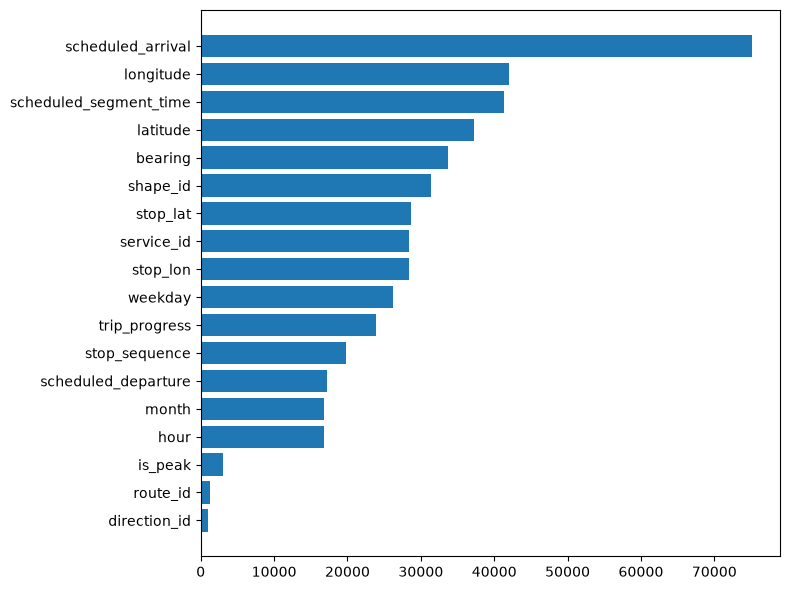

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

fi = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

print(fi)

plt.figure(figsize=(8,6))
plt.barh(fi["Feature"], fi["Importance"])
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()